In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio
from datetime import datetime, timedelta
import geopandas as gpd
from shapely.geometry import Point
from esda.moran import Moran_Local
from libpysal.weights import Queen

data = pd.read_csv('../data/cleaned_2021-jan2025.csv')
data.dropna(subset=['Latitude', 'Longitude'])
data['IncidentDate'] = pd.to_datetime(data['IncidentDate'], format="mixed", dayfirst=False)

len(data)

# FILTER TO 2024
data = data[(data['IncidentDate'] >= '2024-01-01') & (data['IncidentDate'] < '2025-01-01')]

# --------------- CUT OUT POINTS OUTSIDE BOUNDARY

# Load the neighborhood shapefile
city_bounds = gpd.read_file('../data/city_bounds/stl_boundary.shp')


points = gpd.GeoDataFrame(data, geometry=gpd.points_from_xy(data.Longitude, data.Latitude))


# points = points.to_crs(city_bounds.crs)
points.set_crs(epsg=4326, inplace=True)

if city_bounds.crs != points.crs:
    points = points.to_crs(city_bounds.crs)

within_points = gpd.sjoin(points, city_bounds, how='inner', predicate = 'within')

columns_to_drop = ['index_right'] + list(city_bounds.columns)

within_points = within_points.drop(columns=columns_to_drop)

print(len(within_points))
data = within_points

# ------------------- NEIGHBORHOOD SHAPEFILE

neighborhoods = gpd.read_file('../data/neighborhoods/Neighborhoods.shp')

neighborhood_pop = pd.read_csv('../data/neighborhoods/neighborhood_populations.csv')

C:\Users\jz043x\AppData\Local\Temp\ipykernel_17092\2039336378.py:11: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/cleaned_2021-jan2025.csv')


48915


In [38]:
# Load the neighborhood shapefile
neighborhoods = gpd.read_file('../data/neighborhoods/Neighborhoods.shp')

# Aggregate crime data by neighborhood
crime_counts = data.groupby("Neighborhood")["IncidentNum"].count().reset_index(name="CrimeCount")

# Merge crime data with the shapefile
neighborhoods_with_crime = neighborhoods.merge(crime_counts, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_crime = neighborhoods_with_crime.merge(neighborhood_pop, left_on="NHD_NAME", right_on="Neighborhood", how="left")
neighborhoods_with_crime["CrimeCount"] = neighborhoods_with_crime["CrimeCount"].fillna(0)
# neighborhoods_with_crime = neighborhoods_with_crime[~neighborhoods_with_crime['NHD_NAME'].isin(neighborhoods_to_drop)]
# neighborhoods_with_crime = neighborhoods_with_crime[neighborhoods_with_crime['Population'] >= 400]
neighborhoods_with_crime["PopCrime"] = neighborhoods_with_crime["CrimeCount"]/neighborhoods_with_crime["Population"]

# remove neighborhoods with less than 400 residents to not skew data
neighborhoods_with_crime['PopCrime'] = np.where(neighborhoods_with_crime['Population'] < 400, 0, neighborhoods_with_crime['PopCrime'])

outlier_neighborhoods = neighborhoods_with_crime[(neighborhoods_with_crime['Population'] < 400) | (neighborhoods_with_crime['NHD_NAME'] == 'Princeton Heights')]

inlier_neighborhoods = neighborhoods_with_crime[(neighborhoods_with_crime['Population'] > 400) & (neighborhoods_with_crime['NHD_NAME'] != 'Princeton Heights')]



C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 38.
  W.__init__(self, neighbors, ids=ids, **kw)
C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\esda\moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


('WARNING: ', 38, ' is an island (no neighbors)')


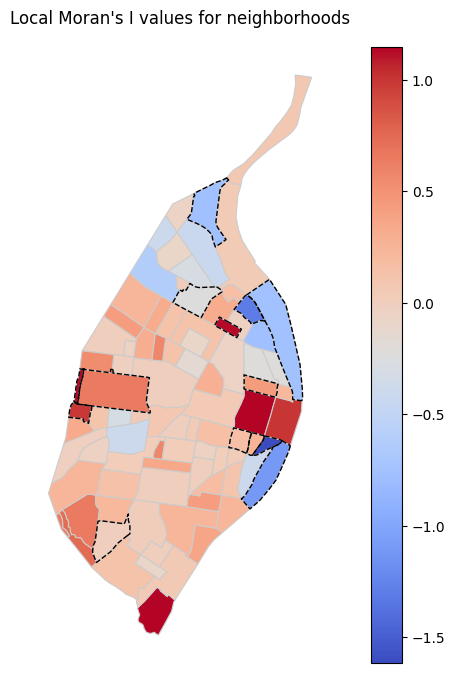

In [39]:
# Create a synthetic numerical attribute for each neighborhood (e.g., population or crime rate)
# Replace this with actual data if available
np.random.seed(42)  # For reproducibility
# neighborhoods_with_crime['PopCrime'] = np.random.randint(100, 1000, size=len(neighborhoods))

# Create a spatial weights matrix using Queen contiguity (neighbors touching)
w = Queen.from_dataframe(neighborhoods_with_crime, use_index=True)

# Calculate local Moran's I values
moran_local = Moran_Local(neighborhoods_with_crime['PopCrime'], w)

# Add the Moran's I values and p-values to the GeoDataFrame
neighborhoods_with_crime['local_moran'] = moran_local.Is
neighborhoods_with_crime['p_value'] = moran_local.p_sim

# Classify the neighborhoods into significant clusters at 0.05 significance level
neighborhoods_with_crime['significant_cluster'] = moran_local.q
neighborhoods_with_crime.loc[neighborhoods_with_crime['p_value'] > 0.05, 'significant_cluster'] = 0

# Plot the neighborhoods with local Moran's I values
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
neighborhoods_with_crime.plot(column='local_moran', cmap='coolwarm', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Local Moran\'s I values for neighborhoods')
ax.set_axis_off()

# Add a legend for significant clusters
significant_clusters = neighborhoods_with_crime[neighborhoods_with_crime['significant_cluster'] != 0]
significant_clusters.plot(ax=ax, color='none', edgecolor='black', linewidth=1, linestyle='--')

# Show the plot
plt.show()

C:\Users\jz043x\AppData\Local\Programs\Python\Python311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


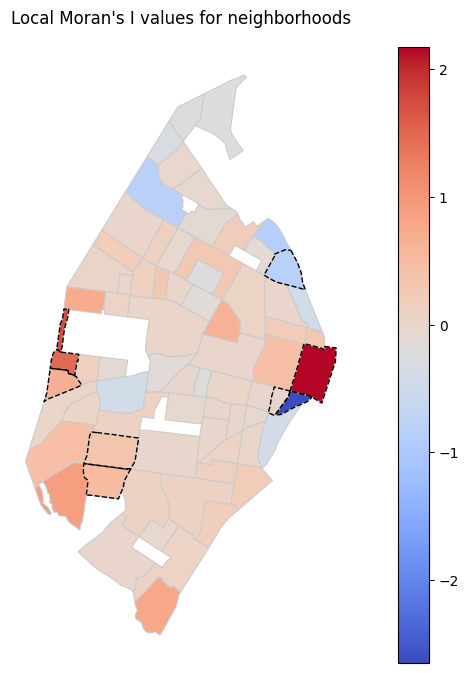

In [35]:
# Create a synthetic numerical attribute for each neighborhood (e.g., population or crime rate)
# Replace this with actual data if available
np.random.seed(42)  # For reproducibility
# inlier_neighborhoods['PopCrime'] = np.random.randint(100, 1000, size=len(neighborhoods))

# Create a spatial weights matrix using Queen contiguity (neighbors touching)
w = Queen.from_dataframe(inlier_neighborhoods, use_index=True)

# Calculate local Moran's I values
moran_local = Moran_Local(inlier_neighborhoods['PopCrime'], w)

# Add the Moran's I values and p-values to the GeoDataFrame
inlier_neighborhoods['local_moran'] = moran_local.Is
inlier_neighborhoods['p_value'] = moran_local.p_sim

# Classify the neighborhoods into significant clusters at 0.05 significance level
inlier_neighborhoods['significant_cluster'] = moran_local.q
inlier_neighborhoods.loc[inlier_neighborhoods['p_value'] > 0.05, 'significant_cluster'] = 0

# Plot the neighborhoods with local Moran's I values
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
inlier_neighborhoods.plot(column='local_moran', cmap='coolwarm', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title('Local Moran\'s I values for neighborhoods')
ax.set_axis_off()

# Add a legend for significant clusters
significant_clusters = inlier_neighborhoods[inlier_neighborhoods['significant_cluster'] != 0]
significant_clusters.plot(ax=ax, color='none', edgecolor='black', linewidth=1, linestyle='--')

# Show the plot
plt.show()

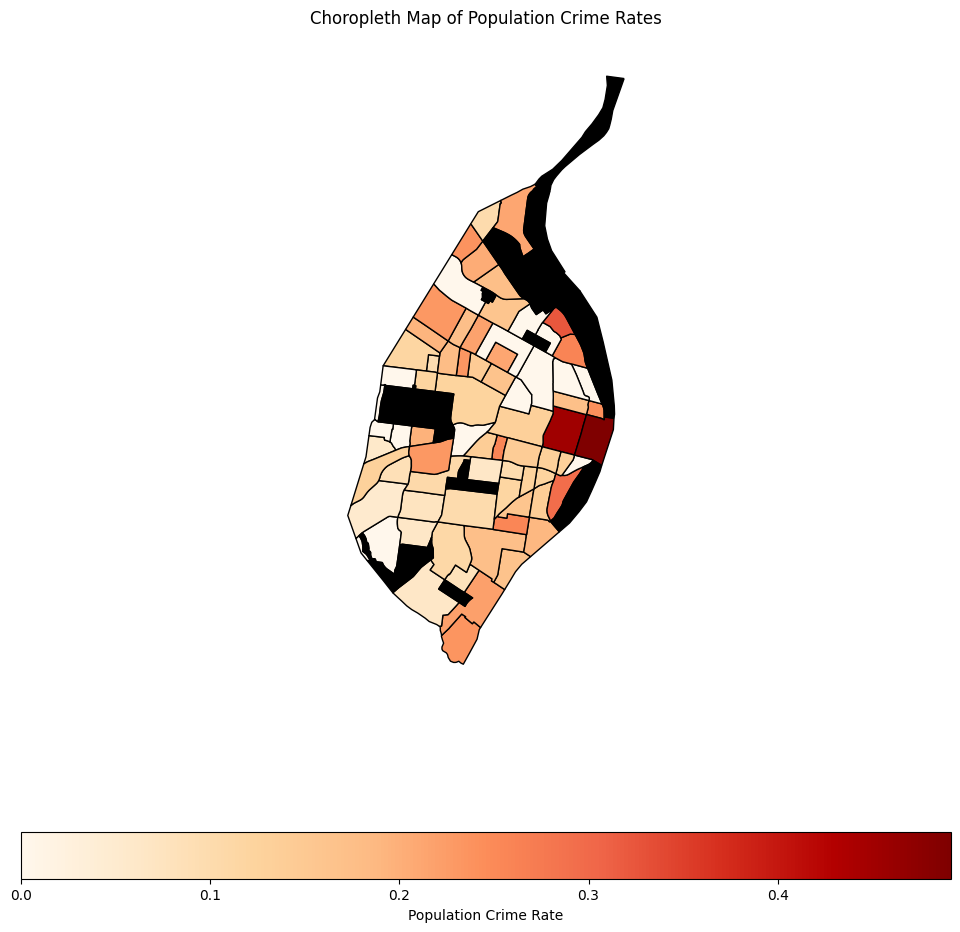

In [36]:

# Plotting the GeoDataFrame with the "PopCrime" column
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
inlier_neighborhoods.plot(column='PopCrime', ax=ax, legend=True,
         legend_kwds={'label': "Population Crime Rate",
                      'orientation': "horizontal"},
         cmap='OrRd',  # OrRd is a colormap from matplotlib; you can choose others like 'viridis', 'plasma', etc.
         edgecolor='black')

# Overlay the second GeoDataFrame with black fill color
outlier_neighborhoods.plot(ax=ax, color='black', edgecolor='black')

# Customize the plot with titles and labels
ax.set_title('Choropleth Map of Population Crime Rates')
ax.set_axis_off()  # Turn off the axis

# Show the plot
plt.show()

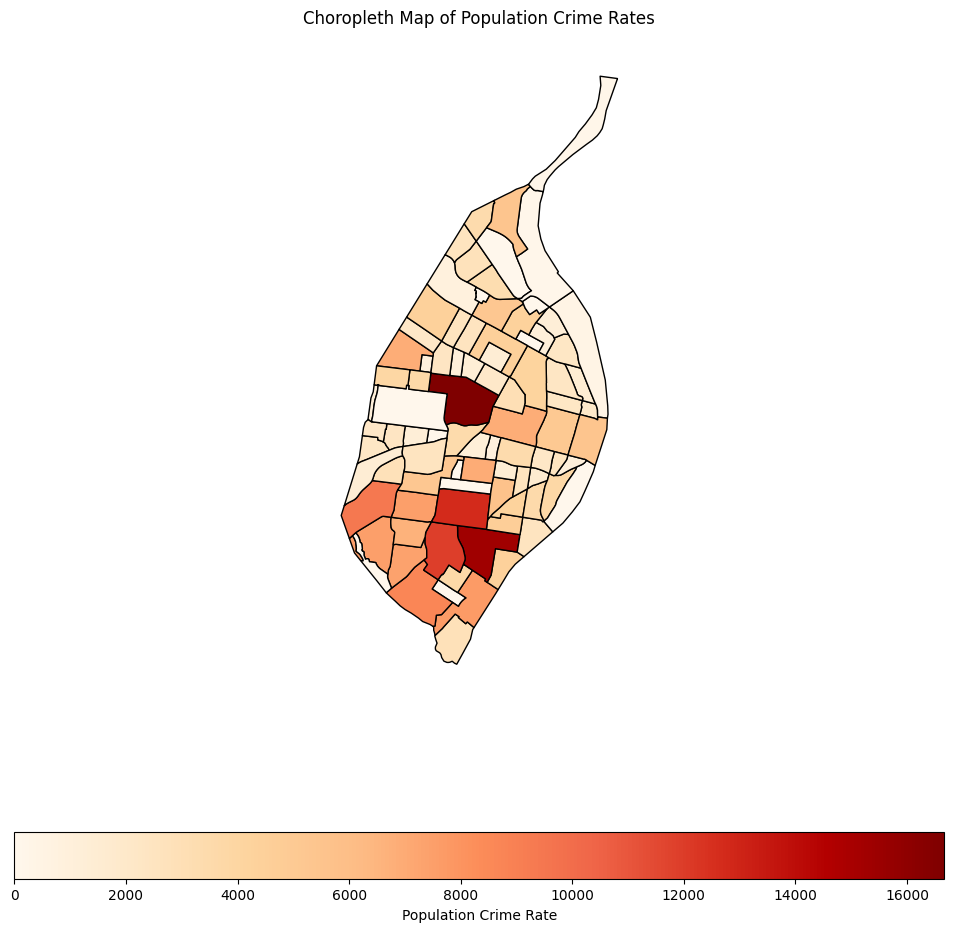

In [40]:

# Plotting the GeoDataFrame with the "PopCrime" column
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
neighborhoods_with_crime.plot(column='Population', ax=ax, legend=True,
         legend_kwds={'label': "Population Crime Rate",
                      'orientation': "horizontal"},
         cmap='OrRd',  # OrRd is a colormap from matplotlib; you can choose others like 'viridis', 'plasma', etc.
         edgecolor='black')


# Customize the plot with titles and labels
ax.set_title('Choropleth Map of Population Crime Rates')
ax.set_axis_off()  # Turn off the axis

# Show the plot
plt.show()